# EDA integral de LATAM Bank · 13 tablas + GPU
**Factored AI & Data Hackathon 2026 · Datos sintéticos · Todo el inventario descargado**

Este notebook sustituye el muestreo exploratorio inicial por un **censo de todas
las filas y columnas de las 13 tablas**. Reúne quejas, problemas técnicos, SLA,
conversaciones, operaciones, satisfacción, clientes, productos y campañas.
Los textos y las uniones se procesan en CPU; los perfiles numéricos se calculan
por bloques en la GPU NVIDIA con CuPy/CUDA. Las salidas son agregadas.

In [1]:
from pathlib import Path
import sys,json,contextlib,io,html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter,PercentFormatter
from IPython.display import display,Markdown,HTML
ROOT=next((p for p in (Path.cwd(),*Path.cwd().parents) if (p/'scripts'/'eda_integral.py').exists()),None)
assert ROOT is not None,'Ejecutar desde el proyecto o notebooks/.'
sys.path.insert(0,str(ROOT/'scripts'))
from eda_integral import run
from validar_integral import validate
OUT=ROOT/'notebooks'/'resultados_integral'
FIG=ROOT/'notebooks'/'figuras_integral';FIG.mkdir(exist_ok=True)
REBUILD=False  # True vuelve a leer y perfilar TODAS las tablas, con CUDA.
pd.set_option('display.max_columns',12);pd.set_option('display.max_rows',15)
pd.set_option('display.float_format',lambda x:f'{x:,.2f}')
BLUE,ORANGE,MUTED,GOLD='#2864A5','#C65D24','#7A8CA2','#BA8B2F'
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':150,'font.size':10,'axes.titlesize':12,
    'axes.spines.top':False,'axes.spines.right':False,'axes.titleweight':'bold',
    'text.color':'#172033','axes.labelcolor':'#334155','figure.facecolor':'white','axes.facecolor':'white'})
def get(name):return pd.read_csv(OUT/f'{name}.csv')
def count(n):return f'{int(n):,}'.replace(',','.')
def pct(n):return f'{n:.2f}'.replace('.',',')+' %'
def showfig(fig,name):
    fig.savefig(FIG/f'{name}.png',bbox_inches='tight');plt.show();plt.close(fig)
def details(title,df):
    display(HTML('<details><summary><b>'+html.escape(title)+'</b></summary>'+df.to_html(index=False,escape=True)+'</details>'))

### Ejecutar el análisis

La primera ejecución requiere el dataset completo y GPU NVIDIA compatible con
CUDA. Instalar `requirements-eda-gpu.txt`. `REBUILD=False` permite reutilizar
perfiles completos verificados por huellas de metadatos; recalcula las consultas
de negocio y la validación. No convierte una muestra en un censo por extrapolación.

In [2]:
run_log=io.StringIO()
with contextlib.redirect_stdout(run_log):
    execution=run(rebuild=REBUILD)
    validation=validate()
coverage=get('coverage');numeric=get('numeric_gpu');columns=get('column_profile')
calls=get('calls_overall').iloc[0];cases=get('complaints_overall').iloc[0]
reason=get('calls_by_reason');tq=get('detalle_transcript_quality').iloc[0]
case_text=get('detalle_case_text_quality').iloc[0]
print(f"Censo calculado: {count(execution['raw_rows'])} filas, {execution['source_files']} archivos, 13 tablas.")

E:\factoredai\.venv\Lib\site-packages\cupy\_environment.py:286: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


Censo calculado: 23.495.188 filas, 7671 archivos, 13 tablas.


## tl;dr

El resumen usa los datos completos. Las etiquetas sintéticas sirven para describir
los registros; su veracidad operativa y semántica se evalúa por separado.

In [3]:
q=reason[reason.reason=='Queja'].iloc[0];t=reason[reason.reason=='Técnico'].iloc[0]
tx=get('transactions_status');declined=tx[tx.status=='Declined'].iloc[0]
sessions=get('digital_session_identity').iloc[0]
links=get('complaint_call_links').iloc[0]
owner_summary=get('integral_owner_consistency').set_index('relation')
wrong_owner=owner_summary.loc['complaints.product.customer']
display(Markdown(f'''| Hallazgo | Censo completo | Interpretación |
|---|---:|---|
| Quejas sin resolución inicial | {count(q.unresolved)} / {count(q.interactions)} ({pct(q.unresolved_pct)}) | Mayor grupo sin resolución por motivo declarado |
| Problemas técnicos sin resolución inicial | {count(t.unresolved)} / {count(t.interactions)} ({pct(t.unresolved_pct)}) | Segundo grupo por volumen sin resolver |
| SLA marcado incumplido | {count(cases.sla_breached)} / {count(cases.cases)} ({pct(cases.sla_breached_pct)}) | Etiqueta; falta la política contractual |
| Casos sin ID de interacción de origen | {count(links.cases-links.declared_links)} / {count(links.cases)} | No se puede enlazar el caso a su conversación por esa llave |
| Casos cuyo producto pertenece a otro cliente | {count(wrong_owner.mismatches)} / {count(wrong_owner.comparable)} comparables | El producto existe, pero no corresponde al cliente del caso |
| Transacciones rechazadas | {count(declined.transactions)} / {count(tx.transactions.sum())} ({pct(declined.pct_sample)}) | Estados observados; no identifica por qué se rechazaron |
| Sesiones con algún evento Error | {count(sessions.error_sessions)} / {count(sessions.sessions)} ({pct(sessions.error_session_pct)}) | Sesiones observadas; no es tasa de fallos por intento |

**Texto:** {count(tq.balance_mentions)} de {count(tq.transcripts)} textos del cliente mencionan saldo.
Los casos tienen {count(case_text.distinct_descriptions)} descripciones distintas.
Quejas y Técnico reúnen {pct((q.unresolved+t.unresolved)/calls.unresolved*100)} de las
interacciones no resueltas, pero esa concentración de etiquetas no demuestra causas ni ahorro potencial.'''))

| Hallazgo | Censo completo | Interpretación |
|---|---:|---|
| Quejas sin resolución inicial | 66.000 / 117.021 (56,40 %) | Mayor grupo sin resolución por motivo declarado |
| Problemas técnicos sin resolución inicial | 30.940 / 102.899 (30,07 %) | Segundo grupo por volumen sin resolver |
| SLA marcado incumplido | 13.495 / 67.095 (20,11 %) | Etiqueta; falta la política contractual |
| Casos sin ID de interacción de origen | 67.095 / 67.095 | No se puede enlazar el caso a su conversación por esa llave |
| Casos cuyo producto pertenece a otro cliente | 44.570 / 44.570 comparables | El producto existe, pero no corresponde al cliente del caso |
| Transacciones rechazadas | 221.234 / 4.425.008 (5,00 %) | Estados observados; no identifica por qué se rechazaron |
| Sesiones con algún evento Error | 319.214 / 1.837.415 (17,37 %) | Sesiones observadas; no es tasa de fallos por intento |

**Texto:** 171.321 de 171.321 textos del cliente mencionan saldo.
Los casos tienen 5 descripciones distintas.
Quejas y Técnico reúnen 60,49 % de las
interacciones no resueltas, pero esa concentración de etiquetas no demuestra causas ni ahorro potencial.

## Context & Methods

**Objetivo:** identificar problemas de atención, calidad y trazabilidad que puedan
sustentar un flujo de la hackathon. No se entrenó un modelo ni se implementaron
acciones bancarias.

- **Fuentes:** los 7.671 CSV del inventario local, el diccionario/resumen del
  organizador y `ANALISIS-REQUISITOS-HACKATHON.md`. Sin consultas a APIs bancarias.
- **Grano:** un registro por ID de cada tabla; tipos de cambio por
  `(date, source_currency, target_currency)`. Unidades diferentes no se suman como
  si fueran casos. «Caso» incluye Complaint, Claim, Request y Suggestion.
- **Limpieza:** blancos a nulo, conversiones explícitas y errores contados. Los
  grupos de clave repetida o nula se excluyen conservadoramente de las métricas de
  negocio hasta revisar su versión. Los perfiles de columnas y GPU usan todas las
  filas originales; la conciliación muestra las exclusiones.
- **Cardinalidad:** `approx_distinct` es una estimación de valores distintos;
  los conteos de filas, claves y métricas de negocio son exactos. Las variantes
  textuales informadas en el análisis de conversaciones se cuentan exactamente.
- **GPU:** CuPy calcula mínimo, máximo, media, desviación poblacional, negativos y
  ceros de los campos numéricos documentados, en bloques de 131.072 filas, con un
  pool limitado a 192 MiB. DuckDB usa hasta 1.500 MB y cuatro hilos para CSV,
  agregaciones categóricas y uniones. Estos límites no son el máximo de memoria
  total de Python o del contexto CUDA. [Instalación oficial de CuPy](https://docs.cupy.dev/en/stable/install.html).
- **Validación GPU:** cada campo se contrasta primero con NumPy en un bloque y
  después con agregaciones independientes de DuckDB sobre **todos** sus valores.
- **Caché:** `dataset/_eda_integral/` guarda las tablas locales. La huella considera
  rutas, tamaño, mtime y configuración; no es un hash criptográfico del contenido.

### Key Assumptions

`was_resolved=False` se interpreta como falta de resolución en el primer contacto,
según el diccionario. `sla_breached` se describe como etiqueta, no como un SLA
recalculado. Estados activos históricos no prueban pendientes actuales. No se
mezclan monedas para estimar pérdidas. No se supone que cliente común o proximidad
temporal identifique el mismo caso. No se atribuye causalidad a asociaciones.

## Data

Las 13 tablas están incluidas. «Filas de análisis» indica lo que queda después del
control de claves, no una muestra. Los volúmenes aproximados del PDF se sustituyen
por recuentos observados; la totalidad de archivos se verifica contra el manifiesto.

In [4]:
display(coverage[['table','files','columns','source_MB','raw_rows','analysis_rows','duplicate_key_groups','null_key_rows']])
display(Markdown(f"**{execution['source_bytes']/1e9:.3f} GB decimales**, "
    f"{count(execution['raw_rows'])} filas; {count(coverage['columns'].sum())} columnas sumadas entre tablas. "
    f"GPU utilizada: **{execution['gpu']['name']}**, CuPy {execution['gpu']['cupy']}."))
display(coverage[['table','seconds_prepare_profile']])
first_execution=json.loads((OUT/'primera_ejecucion.json').read_text(encoding='utf-8'))
display(pd.DataFrame([{'Medición':'Primera lectura y perfilado completo',
    'Segundos':first_execution['wall_seconds'],
    'Pico RSS observado MiB':first_execution['peak_process_RSS_MiB_observed']}]))
display(pd.DataFrame([{'Segundos de esta ejecución (puede reutilizar caché)':execution['wall_seconds'],
    'Pico RSS observado MiB (esta ejecución)':execution['peak_process_RSS_MiB_observed'],
    'Campos numéricos perfilados en CUDA':len(numeric),'Bloque de filas':execution['gpu_batch_rows'],
    'Pool CUDA máximo observado MiB':numeric.pool_peak_MiB.max()}]))
display(Markdown('Los tiempos por tabla corresponden a su preparación original, incluyendo compilaciones '
    'iniciales CUDA cuando ocurrieron. El recálculo con caché no mide lectura desde CSV. '
    'El RSS se muestrea cada 0,2 s y puede omitir picos. **No se afirma que GPU sea más rápida que CPU**: '
    'no se hizo un benchmark equivalente de toda la canalización.'))

,table,files,columns,source_MB,raw_rows,analysis_rows,duplicate_key_groups,null_key_rows
0,branches,1,22,0.09,350,350,0,0
1,customers,1,27,46.90,150000,150000,0,0
2,products,1,17,68.21,400000,400000,0,0
3,service_agents,1,18,0.24,1200,1200,0,0
4,marketing_campaigns,1,13,0.03,200,200,0,0
5,daily_exchange_rates,1,7,0.78,13164,13164,0,0
6,call_center_interactions,1097,21,139.73,686296,686296,0,0
7,call_transcripts,1097,18,137.24,171321,171321,0,0
8,complaints,1097,27,17.99,67095,67095,0,0
9,satisfaction_surveys,1097,20,46.45,212759,212759,0,0


**5.349 GB decimales**, 23.495.188 filas; 260 columnas sumadas entre tablas. GPU utilizada: **NVIDIA GeForce RTX 3050 Ti Laptop GPU**, CuPy 14.2.0.

,table,seconds_prepare_profile
0,branches,26.31
1,customers,26.33
2,products,5.71
3,service_agents,0.16
4,marketing_campaigns,20.91
5,daily_exchange_rates,0.22
6,call_center_interactions,55.05
7,call_transcripts,6.44
8,complaints,15.58
9,satisfaction_surveys,20.87


,Medición,Segundos,Pico RSS observado MiB
0,Primera lectura y perfilado completo,724.40,"2,049.46"


,Segundos de esta ejecución (puede reutilizar caché),Pico RSS observado MiB (esta ejecución),Campos numéricos perfilados en CUDA,Bloque de filas,Pool CUDA máximo observado MiB
0,45.77,"2,040.32",42,131072,7.21


Los tiempos por tabla corresponden a su preparación original, incluyendo compilaciones iniciales CUDA cuando ocurrieron. El recálculo con caché no mide lectura desde CSV. El RSS se muestrea cada 0,2 s y puede omitir picos. **No se afirma que GPU sea más rápida que CPU**: no se hizo un benchmark equivalente de toda la canalización.

## Results

### 1. Calidad e integridad: qué impide confiar en los vínculos

Una referencia nula se distingue de una referencia declarada sin padre y de un
padre con ID repetido. Los nulos pueden ser legítimos según el campo. Un producto
existente tampoco garantiza que pertenezca al cliente indicado en el evento.

In [5]:
relations=get('relations');owners=get('integral_owner_consistency')
display(relations[['child','foreign_key','nonnull_reference','null_reference','absent_parent','ambiguous_parent']])
owners['mismatch_pct_comparable']=owners.mismatches/owners.comparable.replace(0,np.nan)*100
display(owners)
quality=columns[(columns.null_rows>0)|(columns.invalid_type>0)].sort_values('null_pct',ascending=False)
display(quality[['table','column','rows','null_rows','null_pct','invalid_type']].head(15))
display(get('quality_rules'))
display(get('integral_date_domain_rules'))
branch_ref=relations[(relations.child=='customers')&(relations.foreign_key=='registration_branch_id')].iloc[0]
case_owner=owners[owners.relation=='complaints.product.customer'].iloc[0]
display(Markdown(f"**Problemas de integridad confirmados:** {count(case_owner.mismatches)} / "
    f"{count(case_owner.comparable)} casos con producto comparable apuntan a un producto de otro cliente. "
    f"Además, {count(branch_ref.absent_parent)} / {count(branch_ref.nonnull_reference)} referencias "
    'de sucursal de registro de clientes no encuentran su ID en branches. Ambos hallazgos se '
    'comprobaron de nuevo leyendo los CSV con Python. No se corrigieron IDs ni se inventaron enlaces. '
    'En eventos digitales, una referencia a producto tampoco acredita propiedad; el significado '
    'del campo debe aclararse antes de cualquier consulta o acción sobre una cuenta.'))
details('Comprobación independiente sobre CSV originales',pd.DataFrame([json.loads((OUT/'source_crosscheck.json').read_text(encoding='utf-8'))]).T.rename(columns={0:'Valor'}))

,child,foreign_key,nonnull_reference,null_reference,absent_parent,ambiguous_parent
0,customers,registration_branch_id,150000,0,149995,0
1,products,customer_id,400000,0,0,0
2,products,opening_branch_id,400000,0,0,0
3,service_agents,assigned_branch_id,833,367,831,0
4,call_center_interactions,customer_id,686296,0,0,0
...,...,...,...,...,...,...
19,transactions,branch_id,1387932,3037076,0,0
20,digital_events,customer_id,11875548,3745446,0,0
21,digital_events,product_id,1440338,14180656,0,0
22,campaign_sends,customer_id,1746801,0,0,0


,relation,matched_rows,comparable,mismatches,mismatch_pct_comparable
0,transactions.product.customer,4425008,4425008,0,0.00
1,complaints.product.customer,44570,44570,44570,100.00
2,events.product.customer,1440338,1094242,1094226,100.00
3,survey.interaction.customer,212759,212759,0,0.00


,table,column,rows,null_rows,null_pct,invalid_type
153,complaints,origin_interaction_id,67095,67095,100.00,0
255,campaign_sends,conversion_value,1746801,1737002,99.44,0
254,campaign_sends,conversion_date,1746801,1737002,99.44,0
163,complaints,closing_date,67095,64614,96.30,0
168,complaints,resolution_satisfaction,67095,64611,96.30,0
228,digital_events,event_value,15620994,14826484,94.91,0
237,digital_events,utm_campaign,15620994,14782077,94.63,0
235,digital_events,utm_source,15620994,14781949,94.63,0
236,digital_events,utm_medium,15620994,14781860,94.63,0
252,campaign_sends,click_count,1746801,1649008,94.40,0


,rule,affected,eligible
0,call_wait_negative,0,480678
1,call_duration_negative,0,590062
2,call_reason_equals_category,686296,686296
3,first_response_before_creation,0,40853
4,resolution_before_creation,0,15349
5,closing_before_resolution,0,2343
6,resolved_closed_without_resolution_date,772,16121
7,active_status_with_resolution_date,0,50269
8,resolution_days_disagree_elapsed,0,14626
9,outcome_after_process_day,15349,15349


,rule,affected,eligible
0,birth_after_registration,0,150000
1,product_expiration_before_opening,0,133161
2,campaign_end_before_start,0,200
3,negative_exchange_rate,0,13164
4,exchange_buy_gt_sell,0,13164
5,fraud_score_outside_0_100,0,3539851
6,survey_before_interaction,0,212759


**Problemas de integridad confirmados:** 44.570 / 44.570 casos con producto comparable apuntan a un producto de otro cliente. Además, 149.995 / 150.000 referencias de sucursal de registro de clientes no encuentran su ID en branches. Ambos hallazgos se comprobaron de nuevo leyendo los CSV con Python. No se corrigieron IDs ni se inventaron enlaces. En eventos digitales, una referencia a producto tampoco acredita propiedad; el significado del campo debe aclararse antes de cualquier consulta o acción sobre una cuenta.

Valor
"csv.DictReader: todos los productos, clientes y casos"
67095
44570
0
44570
150000
5
0


### 2. Qué tipos de queja hay

Son las subcategorías declaradas en casos, no causas inferidas de la conversación.
El grupo sin subcategoría se conserva. No se les asigna la tasa de no resolución
de las interacciones, porque falta el enlace de origen entre ambas tablas.

,subtype,cases,sla_breached,sla_pct,active_status,repeat_flag,high_critical
0,Cargo no reconocido,12297,2507,20.39,9172,1807,2426
1,Cobro indebido,12194,2431,19.94,9180,1865,2395
2,Problema con app,12128,2429,20.03,9114,1865,2412
3,Atención en sucursal,11892,2421,20.36,8905,1806,2399
4,Calidad de servicio,11886,2412,20.29,8921,1785,2323
5,Sin subcategoría,6698,1295,19.33,4977,958,1290


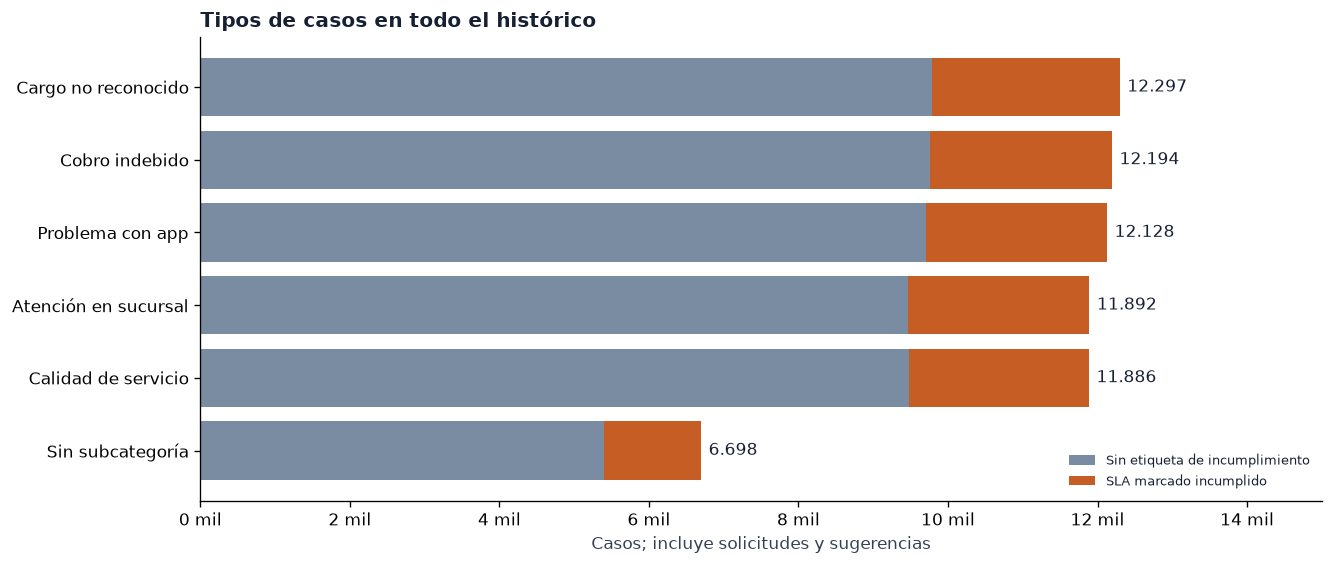

,category,cases,description_known,distinct_descriptions,generic_description,resolution_known,distinct_resolutions
0,Transactions,13580,13580,1,13580,3166,5
1,Fees,13553,13553,1,13553,3057,5
2,Technical,13407,13407,1,13407,3035,5
3,Branch,13361,13361,1,13361,3076,5
4,Service,13194,13194,1,13194,2976,5


Las 67.095 descripciones genéricas no permiten separar comisiones, compras concretas, contraseña, conectividad u otras causas. Las 15.310 resoluciones con texto tienen sólo 5 frases distintas. No prueban la ejecución de un ajuste o pago.

In [6]:
sub=get('detalle_subcategories')
display(sub[['subtype','cases','sla_breached','sla_pct','active_status','repeat_flag','high_critical']])
fig,ax=plt.subplots(figsize=(11,4.6),layout='constrained')
ax.barh(sub.subtype,sub.cases-sub.sla_breached,color=MUTED,label='Sin etiqueta de incumplimiento')
ax.barh(sub.subtype,sub.sla_breached,left=sub.cases-sub.sla_breached,color=ORANGE,label='SLA marcado incumplido')
ax.invert_yaxis();ax.set_xlim(0,sub.cases.max()*1.22)
for y,r in enumerate(sub.itertuples()):ax.text(r.cases+100,y,count(r.cases),va='center')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_:f'{x/1000:.0f} mil'))
ax.set_title('Tipos de casos en todo el histórico',loc='left')
ax.set_xlabel('Casos; incluye solicitudes y sugerencias');ax.legend(loc='lower right',fontsize=8,frameon=False)
showfig(fig,'01_tipos_quejas')
display(get('detalle_generic_text_by_category'))
display(Markdown(f"Las {count(case_text.generic_category_description)} descripciones genéricas "
    'no permiten separar comisiones, compras concretas, contraseña, conectividad u otras causas. '
    f"Las {count(case_text.resolutions_known)} resoluciones con texto tienen sólo "
    f"{count(case_text.distinct_resolution_texts)} frases distintas. No prueban la ejecución de un ajuste o pago."))

### 3. Atención y seguimiento de las interacciones no resueltas

Se compara volumen y tasa dentro del motivo. La etiqueta `requires_followup` no
prueba que una acción de seguimiento se ejecutó. Usarla como predictor del
desenlace del mismo contacto podría introducir fuga de información.

,reason,interactions,unresolved,unresolved_pct,followup,escalated
0,Queja,117021,66000,56.40,73686,11733
1,Técnico,102899,30940,30.07,41763,10367
2,Transaccional,240056,20385,8.49,53137,23841
3,Comercial,54879,19093,34.79,24446,5398
4,Producto,150863,15650,10.37,35923,15021
5,Retención,20578,8198,39.84,10099,2026


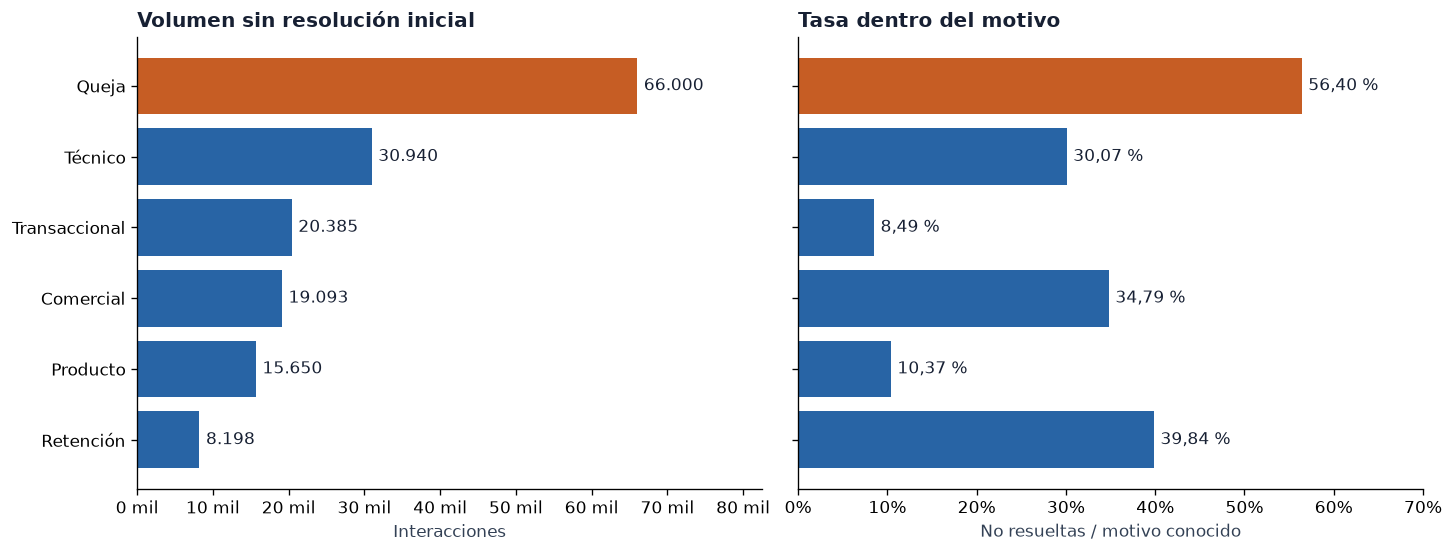

,contact_reason,interactions,unresolved,unresolved_with_followup,unresolved_without_followup,unresolved_escalated,unresolved_without_flags,unresolved_negative,transcript_flag
0,Queja,117021,66000,66000,0,6563,0,23139,29198
1,Técnico,102899,30940,30940,0,3137,0,10816,25691


,channel,interactions,unresolved_pct,wait_known,wait_p50_s,wait_p95_s
0,Phone,583250,23.37,480678,119.00,218.00
1,Email,27543,23.19,0,NaN,NaN
2,App,26364,22.87,0,NaN,NaN
3,WhatsApp,22888,23.42,0,NaN,NaN
4,Web Chat,22856,23.53,0,NaN,NaN
5,Web,3395,23.30,0,NaN,NaN


,eligible_interactions,repeated_within_7d,repeat_pct,customers_observed
0,681903,4564,0.67,148387


In [7]:
display(reason[['reason','interactions','unresolved','unresolved_pct','followup','escalated']])
fig,axs=plt.subplots(1,2,figsize=(12,4.5),layout='constrained',sharey=True)
y=np.arange(len(reason));colors=[ORANGE]+[BLUE]*(len(reason)-1)
b=axs[0].barh(y,reason.unresolved,color=colors);axs[0].set_yticks(y,reason.reason);axs[0].invert_yaxis()
axs[0].set_xlim(0,reason.unresolved.max()*1.25);axs[0].bar_label(b,labels=[count(v) for v in reason.unresolved],padding=4)
axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x,_:f'{x/1000:.0f} mil'))
axs[0].set_title('Volumen sin resolución inicial',loc='left');axs[0].set_xlabel('Interacciones')
b=axs[1].barh(y,reason.unresolved_pct,color=colors);axs[1].set_xlim(0,70)
axs[1].bar_label(b,labels=[pct(v) for v in reason.unresolved_pct],padding=4)
axs[1].xaxis.set_major_formatter(PercentFormatter(100));axs[1].set_title('Tasa dentro del motivo',loc='left')
axs[1].set_xlabel('No resueltas / motivo conocido');showfig(fig,'02_resolucion')
display(get('detalle_focus_outcomes'))
display(get('calls_by_channel')[['channel','interactions','unresolved_pct','wait_known','wait_p50_s','wait_p95_s']])
display(get('repeat_contact'))

La espera sólo se compara donde está registrada; en Phone hay faltantes y en
otros canales puede no aplicar. Contacto repetido en siete días usa cliente y
motivo, excluyendo los primeros siete días del archivo. No demuestra repetición
del mismo caso y no equivale al flag de reclamante repetido en 90 días.

### 4. SLA, prioridad, estado y tiempos

SLA significa compromiso/plazo de atención. No hay una política por caso para
recalcularlo. Los intervalos de 24/48 horas y 7/15/22 días son cortes exploratorios,
no plazos contractuales. Las duraciones de resolución sólo representan casos con
estado Resolved/Closed y duración conocida; no incluyen la espera de los pendientes.

,priority,cases,sla_known,sla_breached,sla_pct,active_and_sla,response_known,response_p50_hours,resolution_p50_days
0,Critical,3355,3355,644,19.20,504,2025,38.00,15.00
1,High,9890,9890,2024,20.47,1501,6096,37.00,16.00
2,Medium,33439,33439,6734,20.14,5056,20378,38.00,16.00
3,Low,20411,20411,4093,20.05,3077,12354,38.00,16.00


,status,cases,with_resolution_date,with_closing_date,sla_breached
0,In Process,26823,0,0,5498
1,Open,20125,0,0,3947
2,Resolved,13512,12880,0,2663
3,Escalated,3321,0,0,693
4,Closed,2609,2469,2481,543
5,Rejected,705,0,0,151


,response_group,cases,sla_breached,sla_pct
0,01: <=24 h,9073,1803,19.87
1,02: 24-48 h,20950,4254,20.31
2,03: >48 h,10830,2231,20.60
3,Sin respuesta registrada,26242,5207,19.84


,duration_group,cases,sla_breached,sla_pct,min_days,max_days
0,01: 0-7 días,3580,696,19.44,1.00,7.00
1,02: 8-15 días,4039,867,21.47,8.00,15.00
2,03: 16-22 días,3513,682,19.41,16.00,22.00
3,04: 23+ días,4231,813,19.22,23.00,30.00
4,Sin duración,758,148,19.53,NaN,NaN


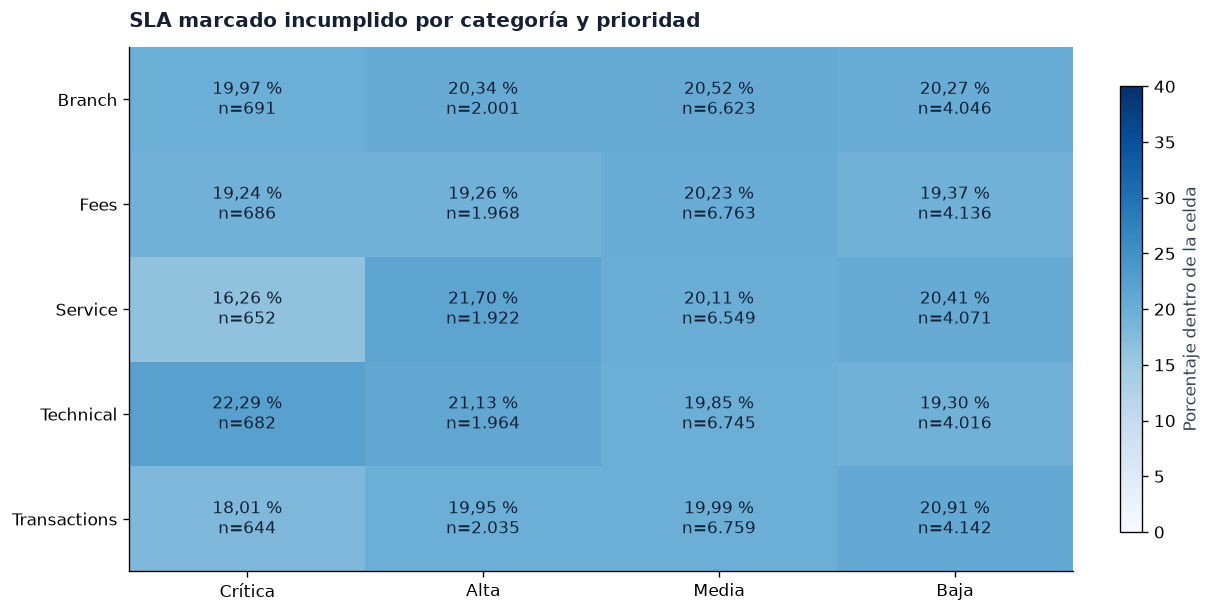

**2.005 registros** combinan prioridad alta/crítica, estado activo y SLA marcado incumplido. Es un corte del histórico, no una lista de pendientes vigentes. Las tasas similares entre duraciones no permiten deducir un plazo ni demuestran que el SLA esté mal etiquetado.

In [8]:
pri=get('detalle_sla_priority');mat=get('detalle_sla_matrix')
display(pri);display(get('complaints_by_status'))
display(get('detalle_sla_response_bins'));display(get('detalle_sla_resolution_bins'))
rates=mat.pivot(index='category',columns='priority',values='sla_pct').reindex(columns=['Critical','High','Medium','Low'])
ns=mat.pivot(index='category',columns='priority',values='cases').reindex_like(rates)
fig,ax=plt.subplots(figsize=(10,5),layout='constrained')
im=ax.imshow(rates,cmap='Blues',vmin=0,vmax=40,aspect='auto')
ax.set_xticks(range(4),['Crítica','Alta','Media','Baja']);ax.set_yticks(range(len(rates)),rates.index)
for i in range(len(rates)):
    for j in range(4):ax.text(j,i,f'{pct(rates.iloc[i,j])}\nn={count(ns.iloc[i,j])}',ha='center',va='center',color='#122237')
ax.set_title('SLA marcado incumplido por categoría y prioridad',loc='left',pad=12)
fig.colorbar(im,ax=ax,label='Porcentaje dentro de la celda',shrink=.85)
showfig(fig,'03_sla')
candidate=pri[pri.priority.isin(['High','Critical'])].active_and_sla.sum()
display(Markdown(f"**{count(candidate)} registros** combinan prioridad alta/crítica, estado activo y SLA marcado incumplido. "
    'Es un corte del histórico, no una lista de pendientes vigentes. Las tasas similares entre '
    'duraciones no permiten deducir un plazo ni demuestran que el SLA esté mal etiquetado.'))

### 5. Problemas técnicos: acciones con Error en todos los eventos

Las tasas son eventos Error divididos por eventos de la misma acción, no intentos
únicos ni clientes. Los eventos sin acción se mantienen en la tabla, aunque no se
grafican como si fueran una acción identificada. Sin logs/códigos de backend no se
atribuyen errores a caída, contraseña, conectividad o saldo.

,action,event_category,events,error_events,error_pct
0,view_transactions,Transaction,901039,54073,6.00
1,initiate_transfer,Transaction,901824,53883,5.97
2,initiate_payment,Transaction,902225,53657,5.95
3,view_help,Navigation,890625,40679,4.57
4,view_accounts,Navigation,892802,40308,4.51
5,view_home,Navigation,890058,40283,4.53
6,view_products,Navigation,891777,40193,4.51
7,Sin acción,Navigation,396062,17872,4.51
8,Sin acción,Transaction,299886,17775,5.93


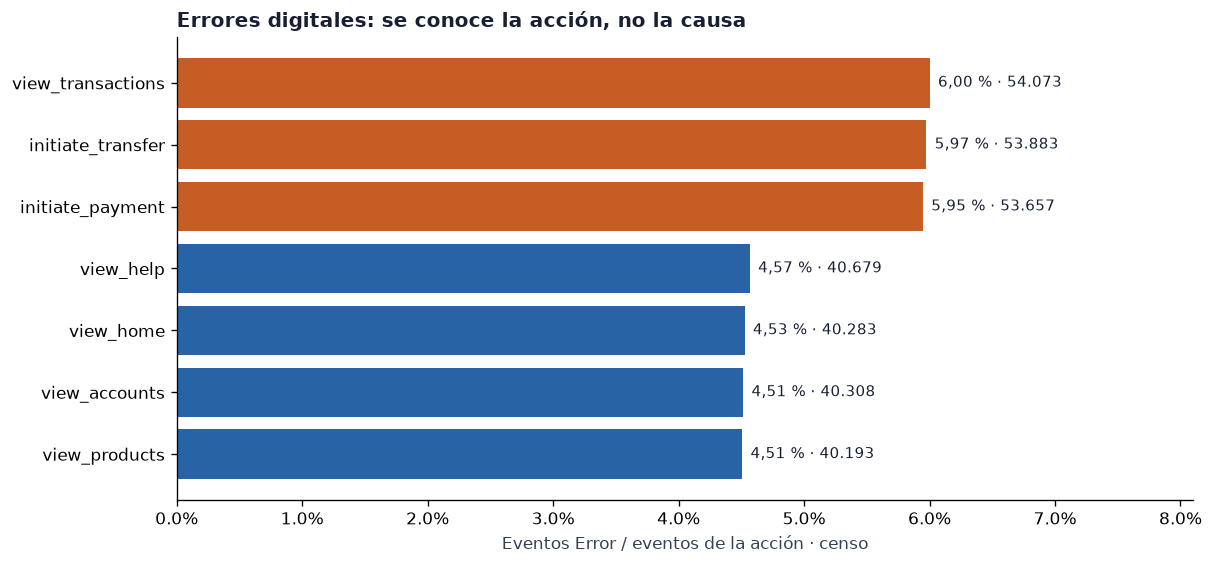

,channel,events,type_known,error_events,error_pct,form_submit_events
0,Android App,5476164,5476164,125974,2.30,209685
1,iOS App,3899497,3899497,89294,2.29,148286
2,Desktop Web,3128851,3128851,71817,2.30,119408
3,Mobile Web,3116482,3116482,71638,2.30,119529


,sessions,anonymous_sessions,multiple_customer_sessions,error_sessions,error_session_pct
0,1837415,367044,0,319214,17.37


In [9]:
actions=get('detalle_technical_actions');display(actions)
visible=actions[actions.action!='Sin acción'].sort_values('error_pct',ascending=False)
fig,ax=plt.subplots(figsize=(10,4.6),layout='constrained')
b=ax.barh(visible.action,visible.error_pct,color=[ORANGE if c=='Transaction' else BLUE for c in visible.event_category])
ax.invert_yaxis();ax.set_xlim(0,max(8,visible.error_pct.max()*1.35))
ax.bar_label(b,labels=[f'{pct(r.error_pct)} · {count(r.error_events)}' for r in visible.itertuples()],padding=5,fontsize=9)
ax.xaxis.set_major_formatter(PercentFormatter(100));ax.set_xlabel('Eventos Error / eventos de la acción · censo')
ax.set_title('Errores digitales: se conoce la acción, no la causa',loc='left');showfig(fig,'04_errores_digitales')
display(get('digital_channels'));display(get('digital_session_identity'))

Una sesión con cualquier Error cuenta una vez. Se comprueba si un ID de sesión
agrupa varios clientes y se cuentan sesiones anónimas. El censo evita recortes de
días intermedios, pero los límites inicial/final del archivo aún pueden truncar
sesiones. Cero eventos Error de una categoría no prueba ausencia de fallos.

### 6. Qué dicen realmente todas las transcripciones

Se examinan todos los archivos de `call_transcripts`. La clasificación por familia
usa prefijos explícitos y los indicadores léxicos usan regex visibles en el código;
no son un modelo validado. Los IDs se verifican antes de interpretar los textos.

,Conteo
transcripts,171321
distinct_transcript_ids,171321
distinct_interaction_ids,171321
matched_interactions,171321
customer_mismatches,0
same_customer,171321
topic_reason_mismatches,0
linked_but_flag_false,0
customer_text_known,171321
distinct_customer_texts,42


,declared_topic,transcripts,balance_mentions,complaint_keyword,technical_keyword,agent_placeholders,matched_interactions,same_customer
0,Transaccional,59786,59786,0,0,59786,59786,59786
1,Producto,37658,37658,0,0,37658,37658,37658
2,Queja,29198,29198,0,0,29198,29198,29198
3,Técnico,25691,25691,0,0,25691,25691,25691
4,Comercial,13808,13808,0,0,13808,13808,13808
5,Retención,5180,5180,0,0,5180,5180,5180


,text_family,transcripts,distinct_exact_texts
0,Plantilla: saldo de tarjeta de crédito,85910,21
1,Plantilla: saldo de cuenta de ahorros,85411,21


,intent,language,transcripts
0,consulta_general,es,162864
1,Sin intención,es,8457


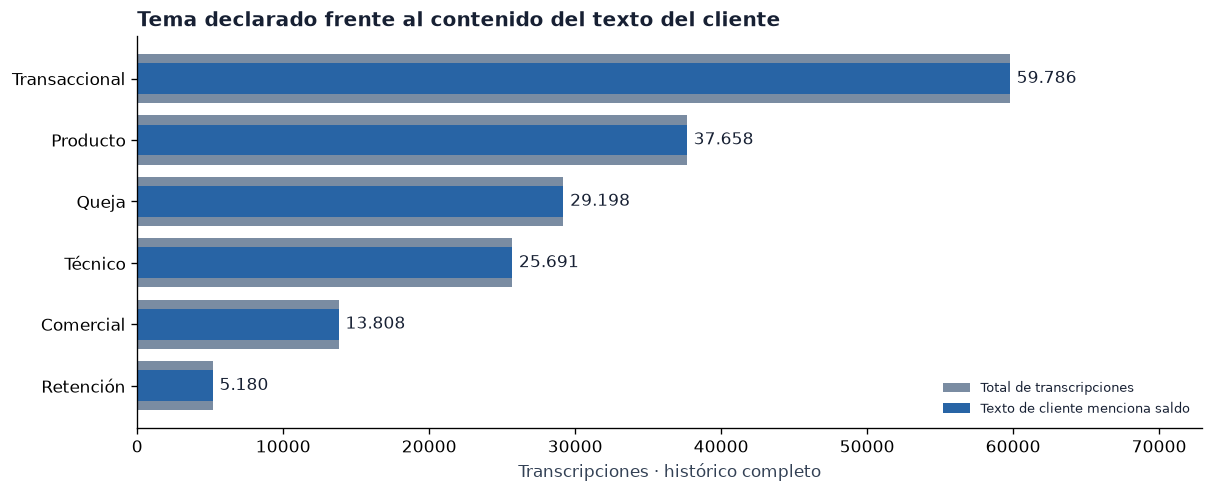

**171.321** respuestas del agente conservan placeholders como `{monto}` o `{moneda}`. Si Queja/Técnico contiene consultas de saldo, la coincidencia de etiquetas entre tablas no valida la semántica. Entrenar y probar con variantes de la misma plantilla puede inflar resultados; separar familias y revisar etiquetas.

In [10]:
topics=get('detalle_transcript_topics');families=get('detalle_text_families')
display(get('detalle_transcript_quality').T.rename(columns={0:'Conteo'}))
display(topics);display(families);display(get('detalle_transcript_metadata'))
fig,ax=plt.subplots(figsize=(10,4),layout='constrained')
y=np.arange(len(topics));ax.barh(y,topics.transcripts,color=MUTED,label='Total de transcripciones')
b=ax.barh(y,topics.balance_mentions,height=.5,color=BLUE,label='Texto de cliente menciona saldo')
ax.set_yticks(y,topics.declared_topic);ax.invert_yaxis();ax.set_xlim(0,topics.transcripts.max()*1.22)
ax.bar_label(b,labels=[count(v) for v in topics.balance_mentions],padding=4)
ax.set_title('Tema declarado frente al contenido del texto del cliente',loc='left')
ax.set_xlabel('Transcripciones · histórico completo');ax.legend(loc='lower right',frameon=False,fontsize=8)
showfig(fig,'05_textos')
display(Markdown(f"**{count(tq.agent_placeholders)}** respuestas del agente conservan placeholders como "
    '`{monto}` o `{moneda}`. Si Queja/Técnico contiene consultas de saldo, la coincidencia '
    'de etiquetas entre tablas no valida la semántica. Entrenar y probar con variantes '
    'de la misma plantilla puede inflar resultados; separar familias y revisar etiquetas.'))

### 7. Transacciones y cobertura monetaria

Un rechazo no se interpreta automáticamente como fraude o error técnico. Un
pendiente puede ser transitorio y un reverso una corrección válida. No se suman
importes de monedas diferentes ni se convierten faltantes USD en cero.

,status,transactions,pct_sample
0,Approved,4070681,91.99
1,Declined,221234,5.00
2,Pending,88343,2.00
3,Reversed,44750,1.01


,channel,transactions,status_known,declined,declined_pct,reversed,pending
0,POS,1548161,1548161,77430,5.00,15785,30983
1,ATM,1328334,1328334,66304,4.99,13447,26497
2,Web,663445,663445,33288,5.02,6678,13235
3,App,663414,663414,32937,4.96,6710,13275
4,Branch,132495,132495,6709,5.06,1252,2556
5,Transfer,89159,89159,4566,5.12,878,1797


,currency,transactions,amount_known,usd_known,usd_missing_pct
0,USD,2437979,2437979,0,100.00
1,COP,1194444,1194444,1135008,4.98
2,ARS,792585,792585,752544,5.05


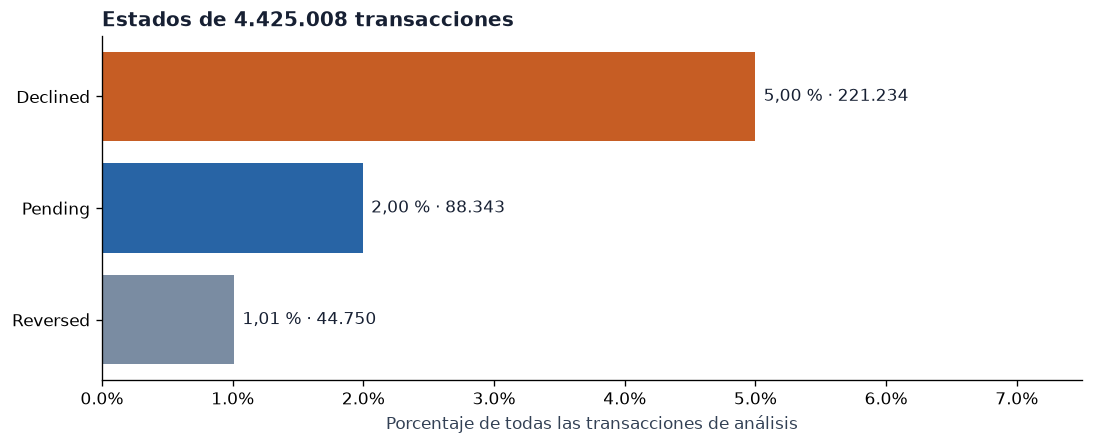

,source_currency,target_currency,rows,days,providers,first_date,last_date,min_rate,max_rate
0,ARS,COP,1097,1097,4,2023-06-17,2026-06-17,11.20,11.66
1,ARS,MXN,1097,1097,4,2023-06-17,2026-06-17,0.05,0.05
2,ARS,USD,1097,1097,4,2023-06-17,2026-06-17,0.00,0.00
3,COP,ARS,1097,1097,4,2023-06-17,2026-06-17,0.09,0.09
4,COP,MXN,1097,1097,4,2023-06-17,2026-06-17,0.00,0.00
5,COP,USD,1097,1097,4,2023-06-17,2026-06-17,0.00,0.00
6,MXN,ARS,1097,1097,4,2023-06-17,2026-06-17,20.18,21.00
7,MXN,COP,1097,1097,4,2023-06-17,2026-06-17,230.60,240.00
8,MXN,USD,1097,1097,4,2023-06-17,2026-06-17,0.06,0.06
9,USD,ARS,1097,1097,4,2023-06-17,2026-06-17,343.01,356.98


,is_fraud,transactions,score_known,mean_fraud_score,approved,declined
0,False,4420692,3536426,15.00,4066695,221019
1,True,4316,3425,49.46,3986,215


In [11]:
display(tx);display(get('transactions_channel'));display(get('integral_currency_usd_coverage'))
problem=tx[tx.status!='Approved']
fig,ax=plt.subplots(figsize=(9,3.6),layout='constrained')
b=ax.barh(problem.status,problem.pct_sample,color=[ORANGE,BLUE,MUTED][:len(problem)])
ax.invert_yaxis();ax.set_xlim(0,max(7,problem.pct_sample.max()*1.5))
ax.bar_label(b,labels=[f'{pct(r.pct_sample)} · {count(r.transactions)}' for r in problem.itertuples()],padding=5)
ax.xaxis.set_major_formatter(PercentFormatter(100));ax.set_title(f'Estados de {count(tx.transactions.sum())} transacciones',loc='left')
ax.set_xlabel('Porcentaje de todas las transacciones de análisis');showfig(fig,'06_transacciones')
display(get('integral_exchange_pairs'))
display(get('integral_fraud_flags'))

La columna heredada `pct_sample` de la consulta significa porcentaje del conjunto
consultado; en esta carpeta integral su denominador es el **censo completo**.
Los tipos de cambio se perfilan por par y fecha, sin sumar tasas entre monedas.
`is_fraud` y `fraud_score` son etiquetas/puntuaciones suministradas; no validan
fraude real ni sirven como verdad independiente para evaluar el mismo sistema que
las produjo. La procedencia del score debe aclararse antes de utilizarlo como predictor.

### 8. Satisfacción: CSAT, NPS y CES se calculan por separado

CSAT favorable = puntuaciones 4–5 entre respuestas válidas 1–5.
NPS = porcentaje de promotores 9–10 menos detractores 0–6 entre respuestas válidas
0–10, expresado en puntos. CES se muestra sin asumir cuál extremo es favorable:
se necesita la formulación de la pregunta. No se promedian juntas las tres escalas.
Las encuestas observadas no representan a todos los clientes o interacciones.
Las escalas registradas también se revisan: en este archivo no aparecen notas 5
de CSAT ni promotores 9–10 de NPS. Esa distribución limita la interpretación y
puede reflejar cómo se generaron los datos sintéticos.

,survey_type,surveys,known_scores,min_score,max_score,mean_score,median_score,comments_known,distinct_comments
0,CES,21235,21235,1.00,4.00,2.77,3.00,10088,8
1,CSAT,127856,127856,1.00,4.00,2.77,3.00,60928,10
2,NPS,63668,63668,2.00,7.00,5.31,6.00,30180,8


,survey_type,surveys,csat_eligible,csat_satisfied,nps_eligible,promoters,detractors,nps_label_disagreement
0,CSAT,127856,127856,14475,0,0,0,0
1,NPS,63668,0,0,63668,0,47438,0
2,CES,21235,0,0,0,0,0,0


,contact_reason,interactions,interactions_with_survey,linked_survey_pct
0,Transaccional,240056,74532,31.05
1,Producto,150863,46566,30.87
2,Queja,117021,36357,31.07
3,Técnico,102899,31802,30.91
4,Comercial,54879,17147,31.25
5,Retención,20578,6355,30.88


**CSAT favorable:** 11,32 % (14.475/127.856 respuestas válidas). **NPS:** -74.51 puntos sobre 63.668 respuestas válidas. Son métricas de este dataset sintético.

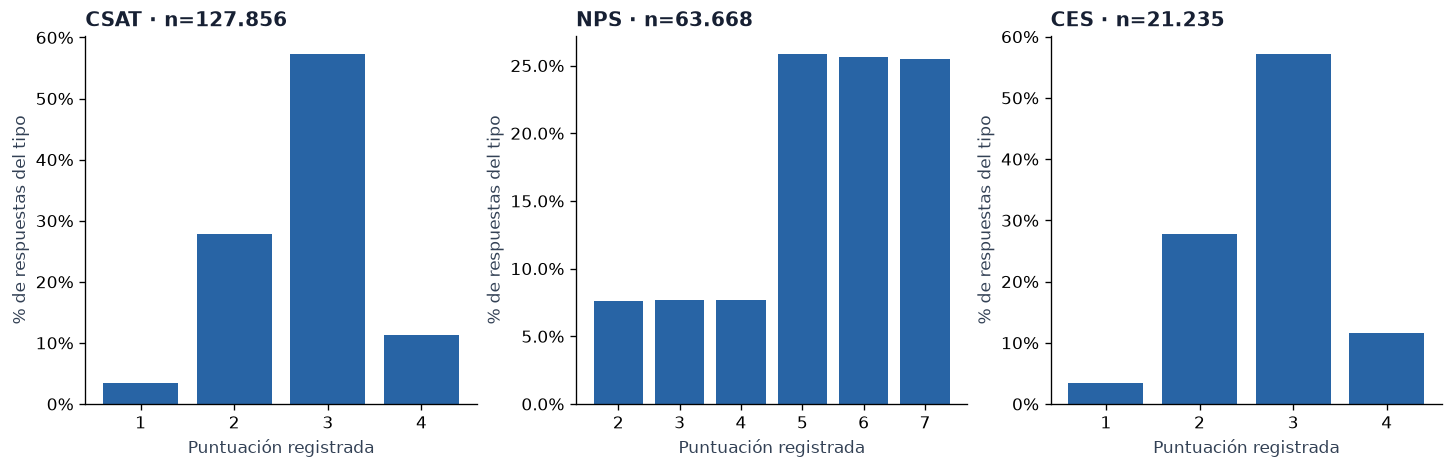

contact_reason,survey_type,was_resolved,surveys,mean_score,score_known
Comercial,CES,False,614,2.00,614
Comercial,CES,True,1146,3.03,1146
Comercial,CSAT,False,3550,2.03,3550
Comercial,CSAT,True,6693,2.99,6693
Comercial,NPS,False,1774,2.97,1774
Comercial,NPS,True,3370,5.99,3370
Producto,CES,False,486,1.99,486
Producto,CES,True,4141,3.02,4141
Producto,CSAT,False,2877,2.01,2877
Producto,CSAT,True,25065,3.00,25065


In [12]:
scores=get('integral_survey_scores');sm=get('integral_survey_metrics');dist=get('integral_survey_distribution')
display(scores);display(sm);display(get('integral_survey_response_coverage'))
cs=sm[sm.survey_type=='CSAT'].iloc[0];np_=sm[sm.survey_type=='NPS'].iloc[0]
display(Markdown(f"**CSAT favorable:** {pct(cs.csat_satisfied/cs.csat_eligible*100)} "
    f"({count(cs.csat_satisfied)}/{count(cs.csat_eligible)} respuestas válidas). "
    f"**NPS:** {(np_.promoters-np_.detractors)/np_.nps_eligible*100:.2f} puntos "
    f"sobre {count(np_.nps_eligible)} respuestas válidas. Son métricas de este dataset sintético."))
fig,axs=plt.subplots(1,3,figsize=(12,3.8),layout='constrained')
for ax,kind in zip(axs,['CSAT','NPS','CES']):
    d=dist[(dist.survey_type==kind)&dist.main_score.notna()]
    total=dist[dist.survey_type==kind].surveys.sum()
    ax.bar(d.main_score,d.surveys/total*100,color=BLUE)
    ax.set_title(f'{kind} · n={count(total)}',loc='left');ax.set_xlabel('Puntuación registrada')
    ax.set_ylabel('% de respuestas del tipo');ax.yaxis.set_major_formatter(PercentFormatter(100))
showfig(fig,'07_satisfaccion')
details('Puntuación por motivo y resolución (sólo enlaces con mismo cliente)',get('integral_survey_resolution'))

### 9. Clientes, productos y capacidad de atención

Estos son estados del archivo, sin fecha de disponibilidad de cada cambio. Las
tasas por experiencia del agente no ajustan mezcla de casos ni prueban desempeño
causal. Morosidad usa `days_past_due`, no un diagnóstico financiero; el denominador
incluye sólo productos del tipo con ese valor conocido.

,country,customers,active,email_known,mobile_known,no_email_or_mobile,credit_score_median
0,México,74907,63804,73394,72548,50,632.00
1,Colombia,45251,38476,44357,43848,29,631.00
2,Argentina,29842,25420,29265,28897,26,631.00


,segment,customers,accepts_marketing
0,Basic,89756,44878
1,Plus,37547,18772
2,Premium,15207,7673
3,Student,7490,3670


,product_type,products,blocked_suspended,dpd_known,with_arrears,over_30_days,over_30_pct_known
0,Cuenta Ahorro,120203,8339,0,0,0,NaN
1,Tarjeta Crédito,100102,6959,95033,14202,9502,10.00
2,Cuenta Corriente,99979,6964,0,0,0,NaN
3,Tarjeta Débito,39938,2945,0,0,0,NaN
4,Préstamo Personal,19960,1398,18993,2840,1882,9.91
5,Préstamo Hipotecario,11910,841,11324,1723,1150,10.16
6,Inversión,5859,403,0,0,0,NaN
7,Seguro,2049,147,0,0,0,NaN


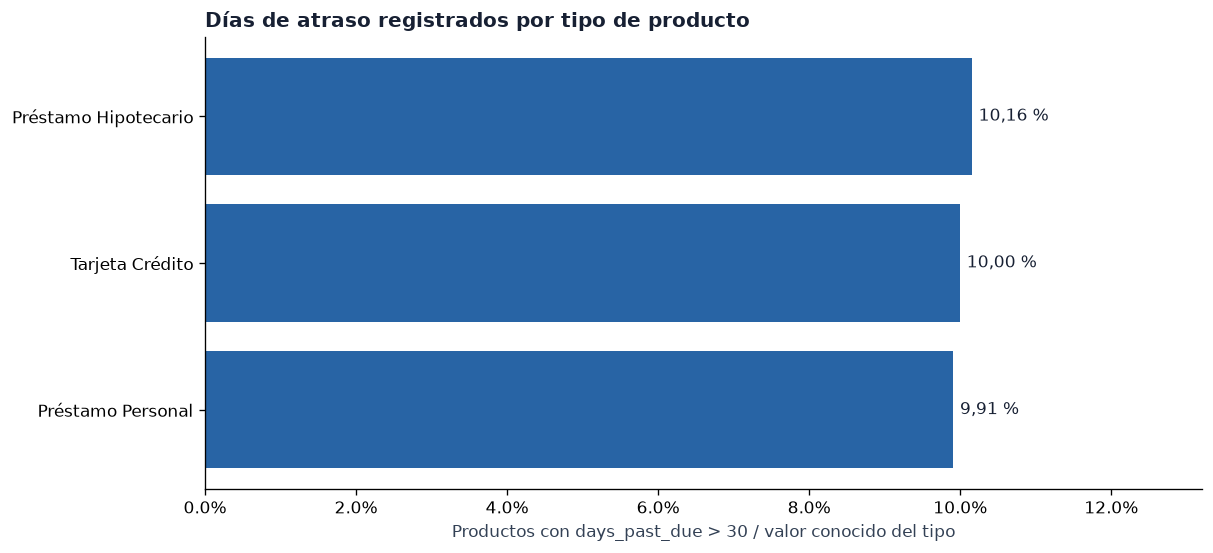

,currency,products,known_balances,median_balance_native_currency,min_balance,max_balance
0,ARS,71524,71524,"854,517.52",0.00,"71,636,132.87"
1,COP,107975,107975,"9,703,803.41",0.00,"881,511,545.61"
2,USD,220501,220501,"2,439.05",0.00,"216,201.46"


,country,branches,active_branches,with_atms,with_tellers
0,Colombia,105,101,105,105
1,Argentina,70,65,70,70
2,México,175,170,175,175


,experience_level,interactions,resolution_known,unresolved,unresolved_pct
0,Specialist,438211,438211,102481,23.39
1,Senior,158820,158820,37218,23.43
2,Mid-Senior,79177,79177,18235,23.03
3,Junior,10088,10088,2332,23.12


In [13]:
display(get('integral_customer_country'));display(get('integral_customer_segment'))
health=get('integral_product_health');display(health)
fig,ax=plt.subplots(figsize=(10,4.5),layout='constrained')
health=health.sort_values('over_30_pct_known',ascending=False)
b=ax.barh(health.product_type,health.over_30_pct_known,color=BLUE)
ax.invert_yaxis();ax.set_xlim(0,max(5,health.over_30_pct_known.max()*1.3))
ax.bar_label(b,labels=[pct(v) if pd.notna(v) else 'Sin dato' for v in health.over_30_pct_known],padding=4)
ax.xaxis.set_major_formatter(PercentFormatter(100));ax.set_xlabel('Productos con days_past_due > 30 / valor conocido del tipo')
ax.set_title('Días de atraso registrados por tipo de producto',loc='left');showfig(fig,'08_productos')
display(get('integral_product_currency'));display(get('integral_branch_country'));display(get('integral_agent_experience'))

### 10. Campañas: entrega, conversión y coherencia temporal

Las tasas usan envíos, no clientes únicos. Apertura, clic y conversión son flags;
no se supone que formen etapas perfectamente anidadas. «Conversión» no significa
que la campaña causó la compra. Consentimiento y estados del cliente son snapshots:
un desacuerdo con envíos históricos requiere trazabilidad, no demuestra una infracción.
WhatsApp y Voice tienen cero conversiones marcadas. Antes de comparar eficacia
entre canales habría que verificar la cobertura de esa medición; los ceros por
sí solos no demuestran que esos canales no conviertan.

,send_channel,sends,delivered,opened,clicked,converted,failed_bounced_blocked,delivery_pct,conversion_pct_all_sends
0,Email,620195,582810,174893,35183,3497,37385,93.97,0.56
1,SMS,432283,406464,202910,40609,4050,25819,94.03,0.94
2,WhatsApp,349144,328329,0,0,0,20815,94.04,0.00
3,Push,290650,273298,109506,22001,2252,17352,94.03,0.77
4,Voice,54529,51143,0,0,0,3386,93.79,0.00


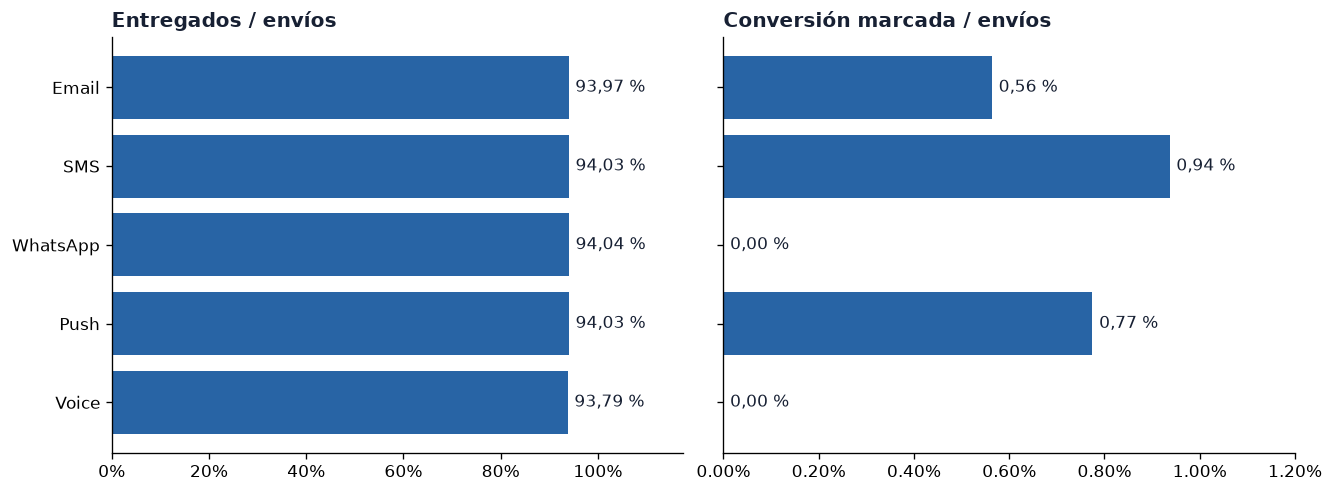

,rule,affected,eligible
0,clicked_without_delivery_flag,0,97793
1,conversion_without_delivery_flag,0,9799
2,open_date_before_send,0,487309
3,click_date_before_send,0,97793
4,conversion_date_before_send,0,9799


,linked_sends,sends_outside_campaign_dates,comparable
0,1746801,8277,1746801


,send_channel,linked_sends,to_customer_flag_no_marketing,marketing_flag_unknown
0,Email,620195,310451,0
1,SMS,432283,216153,0
2,WhatsApp,349144,174745,0
3,Push,290650,145783,0
4,Voice,54529,27285,0


send_channel,send_status,failure_reason,sends
Email,Failed,SMTP error,17785
SMS,Failed,SMTP error,12180
Email,Bounced,Invalid email address,11878
WhatsApp,Failed,SMTP error,9914
SMS,Bounced,Invalid email address,8179
Push,Failed,SMTP error,8172
WhatsApp,Bounced,Invalid email address,6532
Email,Blocked,User blocked sender,5836
Push,Bounced,Invalid email address,5561
SMS,Blocked,User blocked sender,4225


campaign_type,campaign_status,campaigns,first_start,last_end
Email,Completed,57,2023-07-01,2026-07-09
SMS,Completed,36,2023-07-02,2026-05-11
WhatsApp,Completed,33,2023-09-05,2026-07-14
Push,Completed,21,2023-07-06,2026-06-07
Mix,Completed,18,2023-07-10,2026-07-30
Email,Paused,10,2023-07-12,2026-07-20
Voice,Completed,7,2023-12-01,2026-03-23
SMS,Paused,5,2023-11-11,2026-01-24
WhatsApp,Paused,4,2023-08-24,2026-04-04
Mix,Paused,3,2024-02-23,2025-11-04


In [14]:
campaigns=get('integral_campaigns_channel');display(campaigns)
fig,axs=plt.subplots(1,2,figsize=(11,4),layout='constrained',sharey=True)
y=np.arange(len(campaigns))
for ax,col,title in [(axs[0],'delivery_pct','Entregados / envíos'),(axs[1],'conversion_pct_all_sends','Conversión marcada / envíos')]:
    b=ax.barh(y,campaigns[col],color=BLUE);ax.set_xlim(0,max(1.2,campaigns[col].max()*1.25))
    ax.bar_label(b,labels=[pct(v) for v in campaigns[col]],padding=4)
    ax.xaxis.set_major_formatter(PercentFormatter(100));ax.set_title(title,loc='left')
axs[0].set_yticks(y,campaigns.send_channel);axs[0].invert_yaxis();showfig(fig,'09_campanas')
display(get('integral_campaign_rules'));display(get('integral_campaign_date_alignment'))
display(get('integral_consent_send_flags'))
details('Motivos de envíos fallidos / rebotados / bloqueados',get('integral_campaign_failure_reason'))
details('Catálogo de campañas',get('integral_campaign_catalog'))

### 11. Temporalidad y fuga del resultado

`process_date` sólo tiene fecha. Eventos del día siguiente requieren aclarar el
corte del lote y la zona horaria, sin etiquetarlos automáticamente como llegadas
negativas. Fechas de resolución posteriores pueden ser resultados añadidos al
histórico: no deben considerarse conocidas cuando se abrió el caso.

,scope,rows,comparable,process_before_event_day,process_after_event_day,min_lag_days,max_lag_days,p95_lag_days
0,complaints: completo,67095,67095,22585,0,-1,0,0.00
1,interactions: completo,686296,686296,228318,0,-1,0,0.00
2,transactions: completo,4425008,4425008,1106307,0,-1,0,0.00
3,digital_events: completo,15620994,15620994,3930816,0,-1,0,0.00


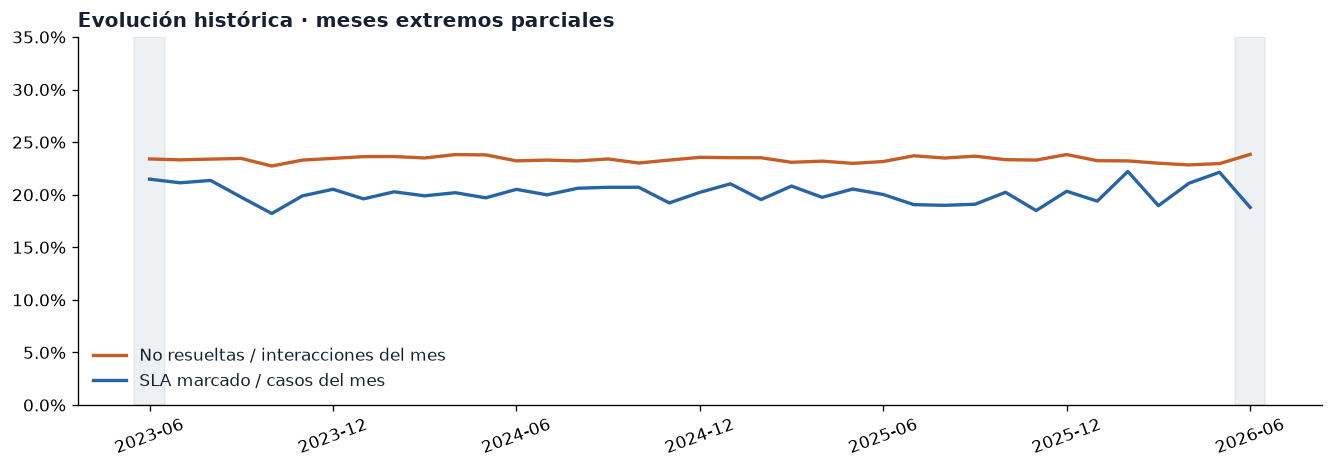

table,column,non_null,minimum,maximum
branches,branch_opening_date,350,1990-01-03 00:00:00,2023-05-11 00:00:00
customers,date_of_birth,150000,1942-07-07 00:00:00,2005-06-21 00:00:00
customers,registration_date,150000,2018-06-18 01:21:11,2026-06-17 23:53:29
customers,last_updated,150000,2018-06-18 15:09:31,2027-06-15 19:35:27
products,opening_date,400000,2018-06-18 00:00:00,2026-06-17 00:00:00
products,expiration_date,133161,2021-06-17 00:00:00,2031-06-16 00:00:00
products,last_transaction_date,305723,2018-06-21 17:07:15,2026-06-17 23:17:43
products,last_updated,400000,2018-06-20 05:21:54,2027-06-15 02:26:58
service_agents,hire_date,1200,2013-06-20 00:00:00,2026-03-17 00:00:00
marketing_campaigns,start_date,200,2023-07-01 00:00:00,2026-06-14 00:00:00


In [15]:
display(get('process_date_lags'))
cm=get('calls_monthly');sm=get('complaints_monthly')
fig,ax=plt.subplots(figsize=(11,3.8),layout='constrained');x=np.arange(len(cm))
ax.plot(x,cm.unresolved_pct,color=ORANGE,lw=2,label='No resueltas / interacciones del mes')
ax.plot(x,sm.sla_breached_pct,color=BLUE,lw=2,label='SLA marcado / casos del mes')
ticks=list(range(0,len(cm),6));ax.set_xticks(ticks,cm.month.iloc[ticks],rotation=20)
ax.set_ylim(0,35);ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.axvspan(-.5,.5,color=MUTED,alpha=.12);ax.axvspan(len(cm)-1.5,len(cm)-.5,color=MUTED,alpha=.12)
ax.set_title('Evolución histórica · meses extremos parciales',loc='left');ax.legend(loc='lower left',frameon=False)
showfig(fig,'10_tiempo')
details('Cobertura de todos los campos de fecha',get('date_profile'))

### 12. Perfiles completos y validación

Los desplegables incluyen **todas las columnas** de cada tabla y todos los campos
numéricos procesados en CUDA. Son conteos y estadísticas; no contienen nombres,
contactos, IDs individuales ni transcripciones. Las medias numéricas son perfiles
técnicos: no equivalen a valores económicos comparables cuando mezclan unidades.

In [16]:
for table in coverage.table:
    d=columns[columns.table==table][['column','rows','non_null','null_pct','approx_distinct','expected_type','invalid_type']]
    details(f'{table}: perfil de todas sus columnas',d)
details('Todos los perfiles numéricos calculados en GPU',numeric[['table','column','rows_examined','finite_values','min','max','mean','std_population','negative','zero']])
details('Comparación independiente GPU vs CPU sobre todos los valores',get('gpu_vs_cpu_full'))
assert validation.passed.all()
display(Markdown(f'**{len(validation)} comprobaciones satisfactorias.** Incluyen conciliaciones, referencias, CSV independiente y perfiles GPU vs CPU completos.'))
details('Detalle de comprobaciones',validation)
tables=[]
for path in sorted(OUT.glob('*.csv')):
    frame=pd.read_csv(path)
    tables.append('<details><summary>'+html.escape(path.name)+'</summary>'
        +frame.to_html(index=False,escape=True)+'</details>')
display(HTML('<details><summary><b>Anexo: todas las tablas de resultados completas ('
    +str(len(tables))+'), sin recortar filas o columnas</b></summary>'
    +''.join(tables)+'</details>'))

column,rows,non_null,null_pct,approx_distinct,expected_type,invalid_type
branch_id,350,350,0.00,416,VARCHAR,0
branch_code,350,350,0.00,342,VARCHAR,0
branch_name,350,350,0.00,171,VARCHAR,0
branch_type,350,350,0.00,4,VARCHAR,0
address,350,350,0.00,318,VARCHAR,0
city,350,350,0.00,16,VARCHAR,0
state,350,350,0.00,18,VARCHAR,0
country,350,350,0.00,3,VARCHAR,0
postal_code,350,350,0.00,107,VARCHAR,0
geographic_zone,350,350,0.00,1,VARCHAR,0


column,rows,non_null,null_pct,approx_distinct,expected_type,invalid_type
customer_id,150000,150000,0.00,173849,VARCHAR,0
document_number,150000,150000,0.00,165394,VARCHAR,0
document_type,150000,150000,0.00,4,VARCHAR,0
first_name,150000,150000,0.00,6810,VARCHAR,0
last_name,150000,150000,0.00,4365,VARCHAR,0
date_of_birth,150000,150000,0.00,26753,TIMESTAMP,0
gender,150000,150000,0.00,3,VARCHAR,0
email,150000,147016,1.99,84951,VARCHAR,0
mobile_phone,150000,145293,3.14,154153,VARCHAR,0
landline_phone,150000,74947,50.04,54920,VARCHAR,0


column,rows,non_null,null_pct,approx_distinct,expected_type,invalid_type
product_id,400000,400000,0.00,467436,VARCHAR,0
customer_id,400000,400000,0.00,172609,VARCHAR,0
product_type,400000,400000,0.00,7,VARCHAR,0
product_number,400000,400000,0.00,424581,VARCHAR,0
currency,400000,400000,0.00,3,VARCHAR,0
current_balance,400000,400000,0.00,341358,DOUBLE,0
credit_limit,400000,125317,68.67,143753,DOUBLE,0
interest_rate,400000,359934,10.02,4057,DOUBLE,0
opening_date,400000,400000,0.00,3237,TIMESTAMP,0
expiration_date,400000,133161,66.71,3689,TIMESTAMP,0


column,rows,non_null,null_pct,approx_distinct,expected_type,invalid_type
agent_id,1200,1200,0.00,1094,VARCHAR,0
employee_code,1200,1200,0.00,1492,VARCHAR,0
first_name,1200,1200,0.00,401,VARCHAR,0
last_name,1200,1200,0.00,1107,VARCHAR,0
email,1200,1200,0.00,1312,VARCHAR,0
phone,1200,1131,5.75,1341,VARCHAR,0
native_accent,1200,1200,0.00,3,VARCHAR,0
country_of_origin,1200,1200,0.00,3,VARCHAR,0
assigned_branch_id,1200,833,30.58,765,VARCHAR,0
agent_type,1200,1200,0.00,4,VARCHAR,0


column,rows,non_null,null_pct,approx_distinct,expected_type,invalid_type
campaign_id,200,200,0.00,207,VARCHAR,0
campaign_name,200,200,0.00,188,VARCHAR,0
description,200,161,19.50,35,VARCHAR,0
campaign_type,200,200,0.00,6,VARCHAR,0
campaign_objective,200,200,0.00,5,VARCHAR,0
promoted_product,200,178,11.00,6,VARCHAR,0
target_segment,200,121,39.50,4,VARCHAR,0
target_country,200,89,55.50,3,VARCHAR,0
start_date,200,200,0.00,214,TIMESTAMP,0
end_date,200,200,0.00,203,TIMESTAMP,0


...

column,rows,non_null,null_pct,approx_distinct,expected_type,invalid_type
send_id,1746801,1746801,0.00,2203531,VARCHAR,0
send_date,1746801,1746801,0.00,1427643,TIMESTAMP,0
process_date,1746801,1746801,0.00,1200,DATE,0
campaign_id,1746801,1746801,0.00,164,VARCHAR,0
customer_id,1746801,1746801,0.00,173849,VARCHAR,0
send_channel,1746801,1746801,0.00,5,VARCHAR,0
template_used,1746801,1571583,10.03,858,VARCHAR,0
subject,1746801,558459,68.03,9,VARCHAR,0
send_status,1746801,1746801,0.00,4,VARCHAR,0
was_delivered,1746801,1746801,0.00,2,BOOLEAN,0


table,column,rows_examined,finite_values,min,max,mean,std_population,negative,zero
branches,atm_count,350,350,2.00,8.00,5.07,2.00,0,0
branches,teller_window_count,350,350,3.00,12.00,7.84,2.86,0,0
branches,latitude,350,350,-34.69,25.78,2.66,15.27,126,0
branches,longitude,350,350,-103.45,0.10,-44.30,43.93,267,0
customers,credit_score,150000,127508,422.00,850.00,647.10,76.85,0,0
customers,estimated_monthly_income,150000,119967,"5,100.28","111,895,075.15","5,895,961.54","14,471,887.91",0,0
products,current_balance,400000,400000,0.00,"881,511,545.61","6,398,475.93","32,924,771.34",0,10918
products,credit_limit,400000,125317,"1,000.33","599,984,205.95","43,180,976.18","94,636,318.29",0,0
products,interest_rate,400000,359934,0.00,45.00,9.98,13.78,0,37768
products,days_past_due,400000,125350,0.00,180.00,12.34,36.48,0,106585


table,column,finite_values_CPU,mean_CPU,mean_GPU,passed
branches,atm_count,350,5.07,5.07,True
branches,teller_window_count,350,7.84,7.84,True
branches,latitude,350,2.66,2.66,True
branches,longitude,350,-44.30,-44.30,True
customers,credit_score,127508,647.10,647.10,True
customers,estimated_monthly_income,119967,"5,895,961.54","5,895,961.54",True
products,current_balance,400000,"6,398,475.93","6,398,475.93",True
products,credit_limit,125317,"43,180,976.18","43,180,976.18",True
products,interest_rate,359934,9.98,9.98,True
products,days_past_due,125350,12.34,12.34,True


**79 comprobaciones satisfactorias.** Incluyen conciliaciones, referencias, CSV independiente y perfiles GPU vs CPU completos.

check,passed,detail
13 tablas examinadas,True,
7671 archivos examinados,True,
Conciliación filas branches,True,
Conciliación filas customers,True,
Conciliación filas products,True,
Conciliación filas service_agents,True,
Conciliación filas marketing_campaigns,True,
Conciliación filas daily_exchange_rates,True,
Conciliación filas call_center_interactions,True,
Conciliación filas call_transcripts,True,


## Takeaways

**Qué se puede afirmar:** el archivo permite medir volumen, resolución etiquetada,
estados, SLA declarado, fricción digital y relaciones entre registros. Los tipos
de queja explícitos permiten delimitar candidatos como cargo no reconocido,
cobro indebido o problema de app. Eso no proporciona automáticamente causas,
reglas del banco ni ejemplos semánticos adecuados para entrenar.

**Qué cambia la decisión:** antes de construir recuperación de casos o un radar
de incidentes, comprobar enlaces y propietarios, revisar la correspondencia de
texto/etiquetas y definir qué información estaba disponible en cada instante.
Los productos de los casos comparables están asociados a clientes distintos y
casi todas las referencias de sucursal de registro no encuentran padre. Estos
enlaces necesitan reparación o escenarios controlados explícitos; no deben
autorizar operaciones por el simple hecho de que el ID del producto exista.
Un log con flag de seguimiento o frase de resolución no acredita una acción
ejecutada. Las afirmaciones de resolución deben apoyarse en estado verificable
de herramientas y en casos de prueba explícitos.

**Para el hackathon:** elegir un flujo, documentar sus límites y probar resolución
normal, ambigüedad y derivación humana. Comparar el componente aprendido con un
baseline y reservar casos por tiempo/cliente/familia textual según corresponda.
Mantener español y portugués en la evaluación; la cobertura bilingüe no se deduce
de datos etiquetados sólo en español. No se ha elegido ni desplegado una solución.

**Reproducción:** `requirements-eda-gpu.txt`, `scripts/eda_integral.py`,
`scripts/validar_integral.py`, `scripts/crear_notebook_integral.py` y los SQL de
`sql/eda/`, `sql/eda_detalle/`, `sql/eda_integral/`. Las carpetas `resultados_integral/`
y `figuras_integral/` son acompañantes auditables; las salidas principales ya están
guardadas en este ipynb. Las tablas originales y la caché permanecen en `dataset/`,
fuera de Git. Las versiones exploratorias previas no definen los denominadores
del presente notebook integral.

In [17]:
details('Registro de ejecución y dispositivo CUDA',pd.DataFrame([
    {'Dato':'Ejecución UTC','Valor':execution['executed_at_utc']},
    {'Dato':'GPU','Valor':execution['gpu']['name']},
    {'Dato':'CuPy / CUDA runtime','Valor':str(execution['gpu']['cupy'])+' / '+str(execution['gpu']['cuda_runtime'])},
    {'Dato':'Motor tabular','Valor':execution['engine_tabular']},
    {'Dato':'Python','Valor':execution['python']},
    {'Dato':'Alcance','Valor':execution['scope']},
]))

Dato,Valor
Ejecución UTC,2026-09-26T02:24:28.213070+00:00
GPU,NVIDIA GeForce RTX 3050 Ti Laptop GPU
CuPy / CUDA runtime,14.2.0 / 12090
Motor tabular,DuckDB 1.5.5
Python,3.12.14
Alcance,CENSO: todas las filas y columnas de las 13 tablas; sin muestreo
